Introduction to Neural Networks

Neural networks power modern AI — from image recognition to large language models. Today you will
understand the brain analogy, learn how a network learns step by step, then build your first real neural network
in Keras targeting 97%+ accuracy on MNIST. No heavy maths today — intuition and implementation is the goal.

Neural networks are machine learning models that mimic the complex functions of the human brain. These models consist of interconnected nodes or
neurons that process data, learn patterns and enable tasks such as pattern recognition and decision-making

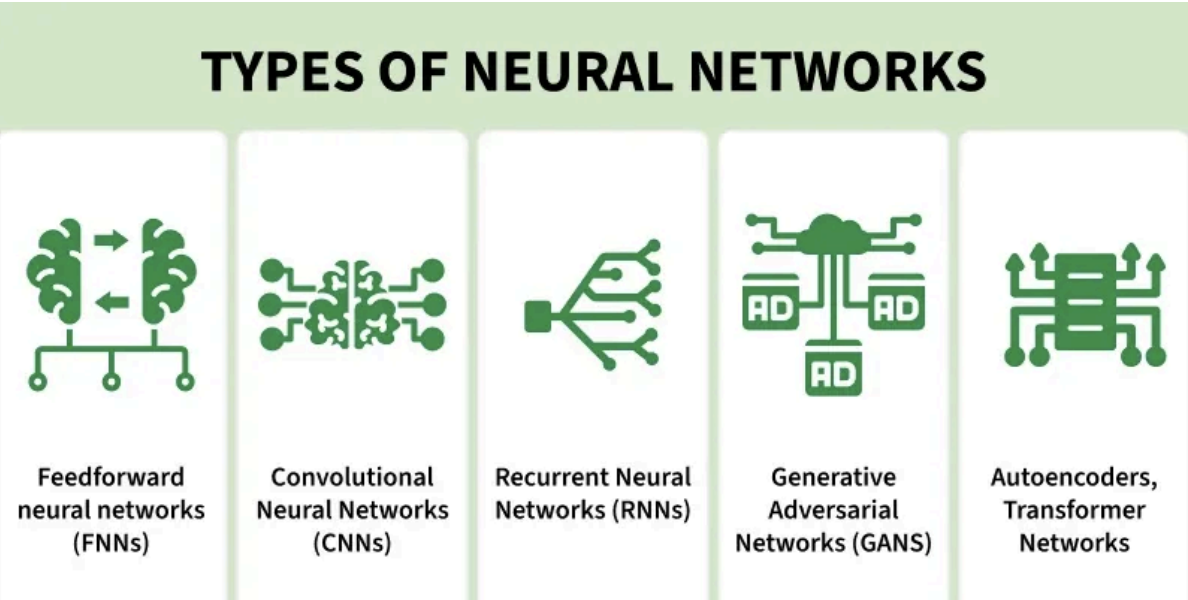

Neural networks are capable of learning and identifying patterns directly from data without pre-defined rules. These networks are built from several key
components:

Neurons: The basic units that receive inputs, each neuron is governed by a threshold and an activation function.

Connections: Links between neurons that carry information, regulated by weights and biases.

Weights and Biases: These parameters determine the strength and influence of connections.

Propagation Functions: Mechanisms that help process and transfer data across layers of neurons.

Learning Rule: The method that adjusts weights and biases over time to improve accuracy.

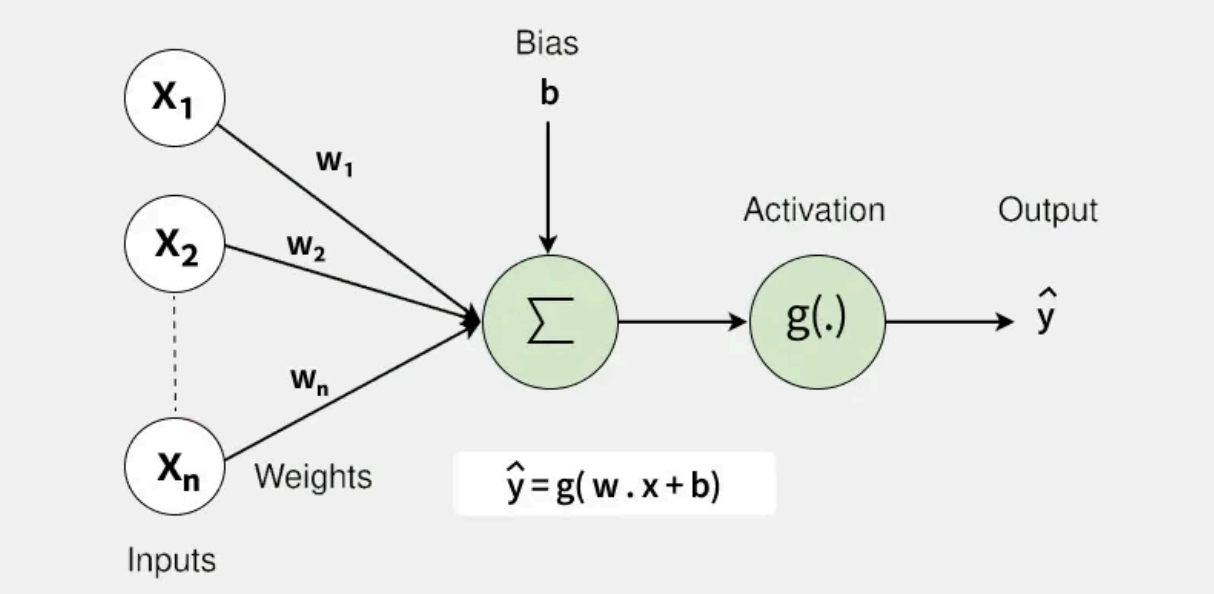

The Human Brain Analogy

Biological Neurons — How Your Brain Works

Your brain contains about 86 billion neurons. Each neuron is a tiny cell that receives electrical signals from other
neurons through connections called synapses. When enough signals arrive, the neuron fires — it sends its own
signal forward to the next layer of neurons. This chain of firing neurons is how you recognise a face, read these
words, or remember a name.


No single neuron understands a face. Thousands of neurons work together — early ones detect edges, middle ones
detect shapes, later ones detect eyes and noses. Recognition emerges from cooperation. Artificial neural networks
copy this exact idea.

From Neuron to Artificial Neuron

The Artificial Neuron — Step by Step

Step 1 — Receive inputs: Numbers arrive as inputs. For an image, these are pixel values. For a house price
model, they might be square footage and location.

Step 2 — Multiply by weights: Each input is multiplied by a weight — a number the network has learned. High
weight = this input matters a lot. Low weight = this input barely matters.

Step 3 — Sum everything: Add all weighted inputs together, then add one more learnable number called a bias
(shifts the result up or down).

Step 4 — Apply activation function: Pass the sum through a function that squashes it into a useful range and
adds non-linearity.

Step 5 — Output: One number leaves this neuron and goes to the next layer.

The Neuron Formula

output = activation( w1*x1 + w2*x2 + ... + wn*xn + bias )

In compact matrix form (how computers actually compute it):

output = activation( W · x + b )

W is a matrix of weights, x is the input vector, b is the bias vector. The dot product W·x computes all weighted sums
at once using matrix multiplication — fast, efficient, and the same on a GPU with millions of neurons.

Weights and Bias — What the Network Actually Learns

When we say a neural network learns, exactly two things change: weights and biases. The architecture (number of
layers, neurons per layer) is fixed before training. Training is the process of finding the right values for every weight
and bias.

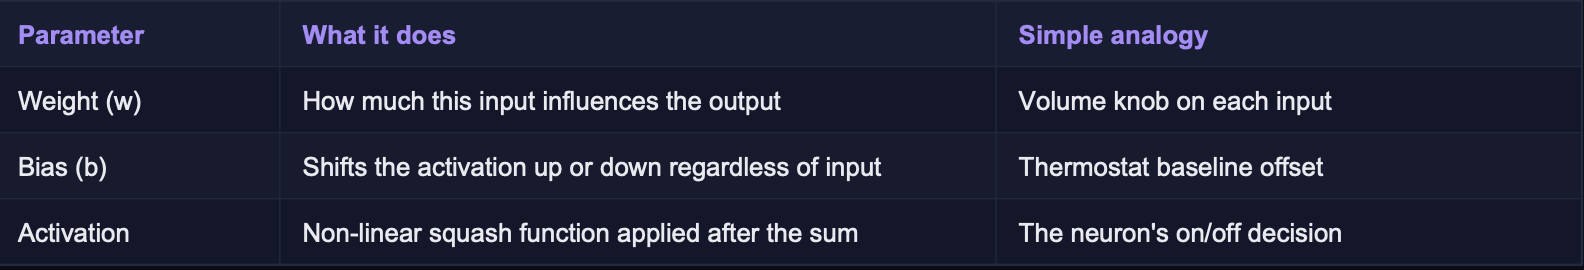

Why Do We Need Activation Functions?

The Non-Linearity Problem

If you chain 10 layers of pure matrix multiplications (no activation functions), the entire network is mathematically
equivalent to a single matrix multiplication. Depth gives you nothing. You can replace 10 layers with 1 and get
identical results.

Activation functions break this by introducing non-linearity. With non-linear activations, a network with enough
neurons can approximate any continuous function — this is the Universal Approximation Theorem, the
mathematical foundation of deep learning.

Activation Functions — Intuition First

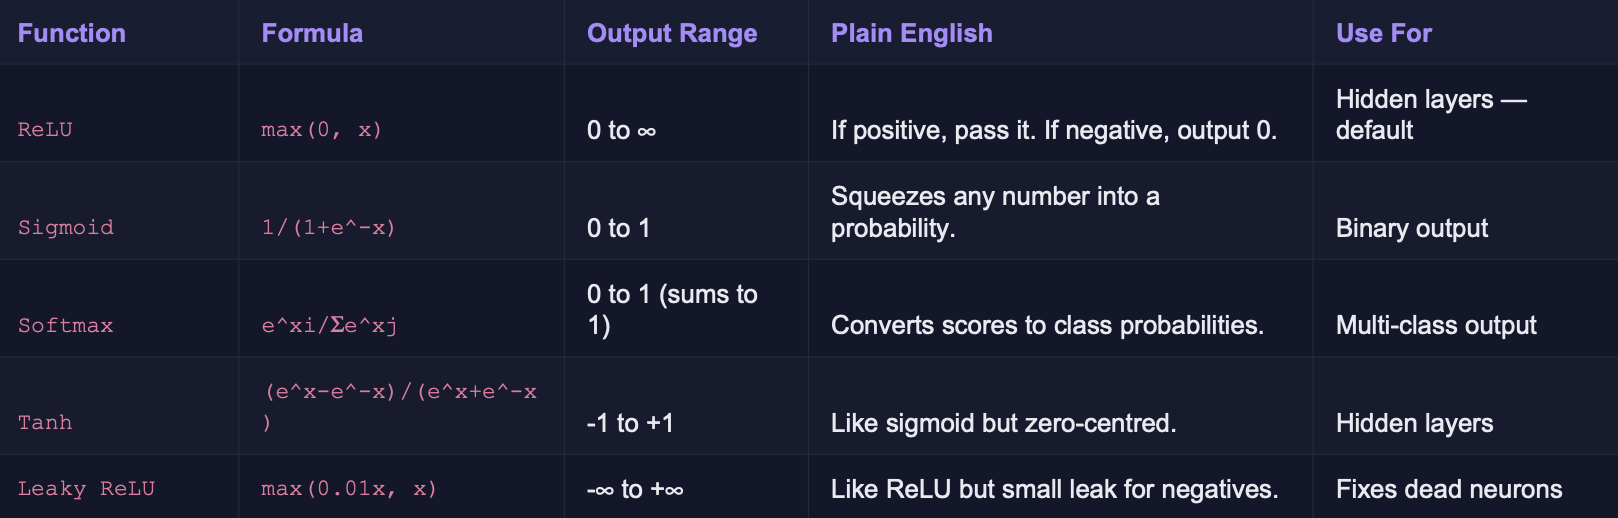

ReLU is the default choice for hidden layers today. It is simple, fast, and avoids the vanishing gradient problem that
plagued older sigmoid-only networks. Use Softmax on the output layer for multi-class problems — it ensures all class
probabilities add up to 1.0.

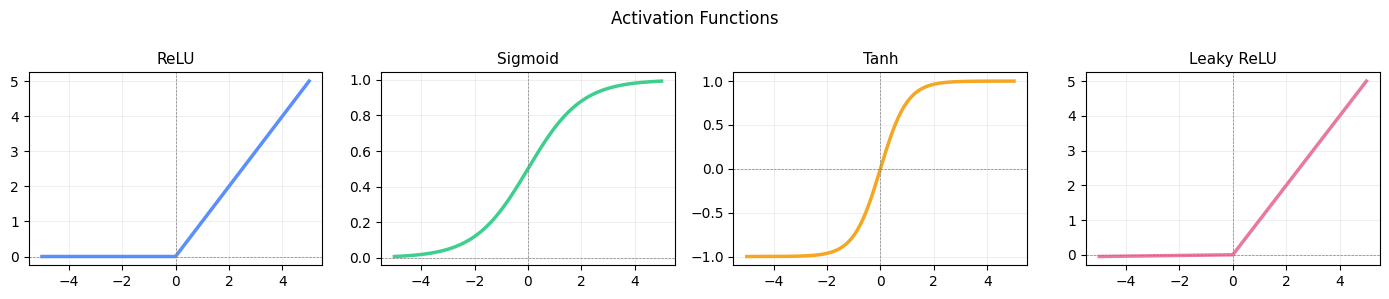

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(-5, 5, 300)

# ■■ Define activation functions ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■

relu = lambda x: np.maximum(0, x)
sigmoid = lambda x: 1 / (1 + np.exp(-x))
tanh_fn = np.tanh
leaky = lambda x: np.where(x > 0, x, 0.01 * x)






fig, axes = plt.subplots(1, 4, figsize=(14, 3))
fns = [relu, sigmoid, tanh_fn, leaky]
names = ['ReLU', 'Sigmoid', 'Tanh', 'Leaky ReLU']
cols = ['#5B8FF9','#3ECF8E','#F5A623','#E879A0']

for ax, fn, name, col in zip(axes, fns, names, cols):
  ax.plot(x, fn(x), color=col, linewidth=2.5)
  ax.axhline(0, color='gray', lw=0.5, ls='--') # x-axis
  ax.axvline(0, color='gray', lw=0.5, ls='--') # y-axis
  ax.set_title(name, fontsize=11)
  ax.grid(alpha=0.2)
plt.suptitle('Activation Functions', fontsize=12)
plt.tight_layout(); plt.show()


Building a Neural Network

The Three Types of Layers

Every neural network has the same basic structure — data enters at the left, flows through the middle, and exits at
the right:

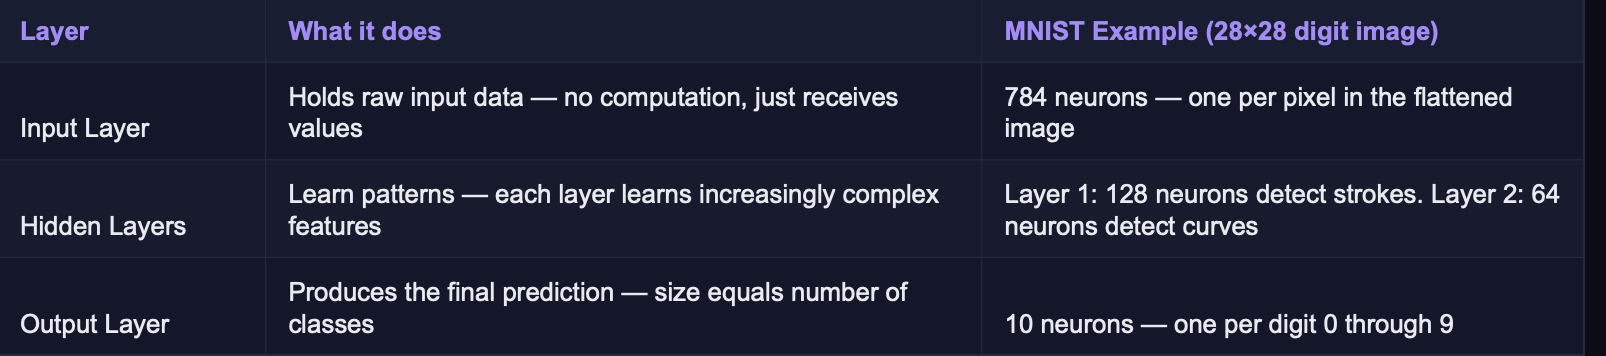

start with 1-2 hidden layers. Add more only if the model cannot fit the data. More layers = more
expressive but harder to train and easier to overfit.

The Forward Pass — Data Flowing Through

Step by Step: Classifying the Digit '7'

Input: The 28×28 image is flattened to 784 numbers (pixel values 0.0–1.0 after normalisation).

Hidden Layer 1 (128 neurons): Each neuron computes W·x + b then applies ReLU. Output: 128 numbers
encoding learned features like diagonal strokes and horizontal bars.

Hidden Layer 2 (64 neurons): Receives the 128 features and combines them into 64 higher-level
representations — partial shapes, digit-like structures.

Output Layer (10 neurons): Produces 10 raw scores. Softmax converts these to probabilities that sum to 1.0.


Prediction: [0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.90, 0.02, 0.01] → highest at index 7 → predicted digit is 7.
✓

Loss Function — Measuring How Wrong We Are

After the forward pass, we compare the prediction to the true label. The loss function converts the error into a
single number. The goal of training is to minimise this number.

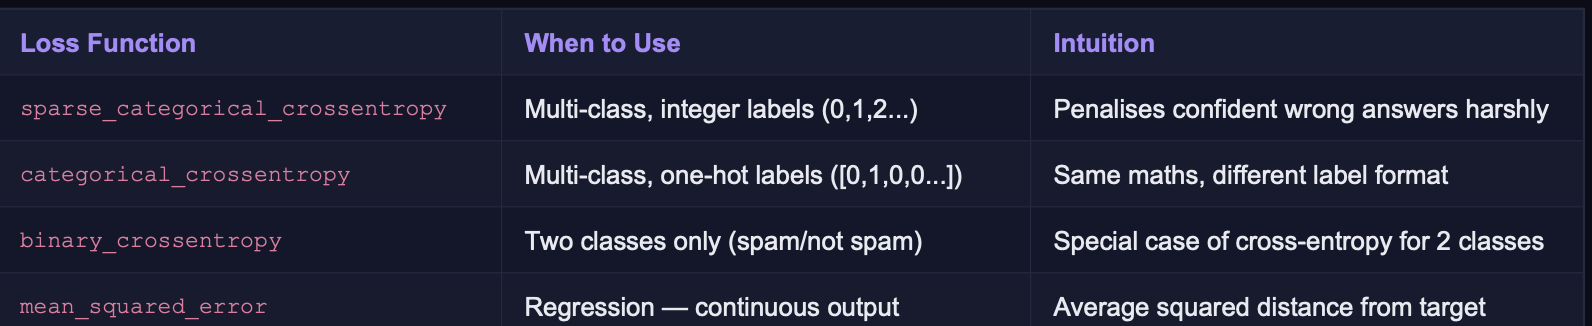

Cross-entropy is large when the model confidently predicts the wrong class, and near zero when it confidently
predicts the correct class. This is exactly the behaviour we want — punish arrogant mistakes.

Backpropagation — How the Network Corrects Its Mistakes

**Backprop in Plain English**

After computing the loss, we need to adjust weights to reduce it. Backpropagation answers: how much did each
weight contribute to this mistake?


The Chain Rule: Calculus tells us how to compute the gradient of the loss with respect to every single weight in
the network — even weights deep in early layers. We chain the derivatives layer by layer, backward from the
output.


The Update: Once we have the gradient for each weight, we nudge it slightly in the direction that reduces the
loss: new_weight = old_weight − learning_rate × gradient


Repeat: Do this for every batch of training examples, every epoch. The network gets a little better each time
until loss plateaus.

new_weight = old_weight − learning_rate × gradient

If the gradient is positive (increasing the weight increases the loss), we decrease the weight. If negative, we
increase it. The learning rate controls the step size — too large and we overshoot, too small and training takes
forever. Adam optimiser handles this automatically.

Gradient Descent Variants

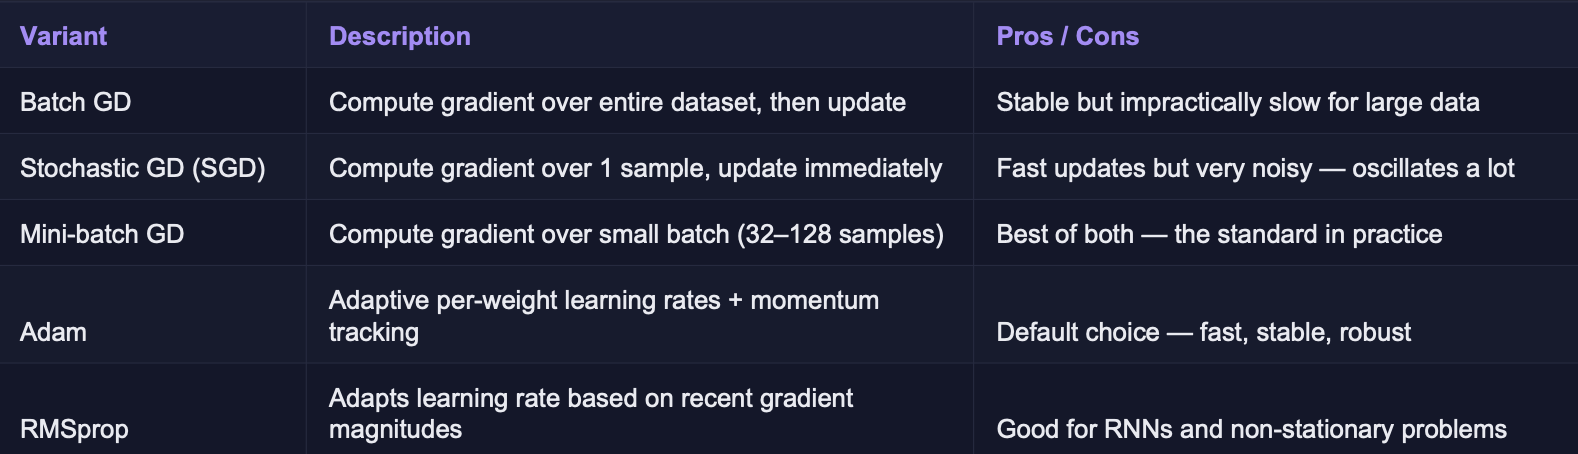

Epochs and Batch Size

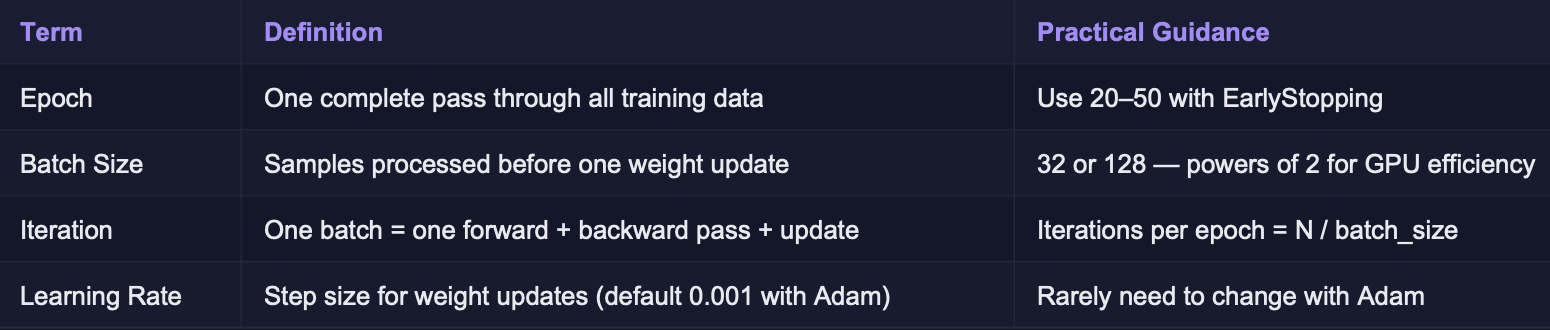

Overfitting vs Underfitting — What the Loss Curves Tell You

Healthy training: Both train loss and val loss decrease and run close together. Model is learning genuine
patterns.


Overfitting: Train loss keeps dropping but val loss starts rising. Model has memorised training data. Fix: add
Dropout, reduce model size, get more data.


Underfitting: Both losses are high and barely decreasing. Model is too simple. Fix: add more neurons, more
layers, train longer

Your First Neural Network with Keras

What is Keras?

Keras is a high-level Python library built on top of TensorFlow. It lets you build, train, and evaluate neural networks
using simple, readable code — without writing the backpropagation algorithm or GPU matrix operations yourself.

The Four Keras Steps

1. Build: Stack layers with keras.Sequential(). Each Dense layer is a fully connected layer where every neuron
connects to every neuron in the next layer.

2. Compile: Choose your loss function (what to minimise) and optimiser (how to minimise it). This is where you
wire up the learning machinery.

3. Fit: Call model.fit() with your data. Keras runs the training loop — forward pass, loss, backprop, update — for
every batch and every epoch.

4. Evaluate: Call model.evaluate() on test data you have never trained on. This is your true accuracy number.

Building the Model — Annotated Line by Line

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


# ■■ Step 1: Load MNIST ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()


# ■■ Step 2: Preprocess ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
print(f'Train: {X_train.shape} Test: {X_test.shape}')



# ■■ Step 3: Build the model ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
model = keras.Sequential([
keras.Input(shape=(784,)),

layers.Dense(234, activation='relu'),
layers.Dropout(0.2),

layers.Dense(64, activation='relu'),
layers.Dropout(0.2),

layers.Dense(10, activation='softmax'),
])
model.summary()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 784) Test: (10000, 784)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 234)            │       183,690 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 234)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        15,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 199,380 (778.83 KB)

 Trainable params: 199,380 (778.83 KB)

 Non-trainable params: 0 (0.00 B)

Compile and Train

In [ ]:
# ■■ Step 4: Compile ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)



# ■■ Step 5: Callbacks — smart training ■■■■■■■■■■■■■■■■■■■■■■■
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


early_stop = EarlyStopping(monitor='val_loss', patience=5,
restore_best_weights=True, verbose=1)


# Halve learning rate if val_loss stalls for 3 epochs
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
patience=3, min_lr=1e-6, verbose=1)




# ■■ Step 6: Train ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
history = model.fit(
X_train, y_train,
epochs=50,
batch_size=128,
validation_split=0.1,
callbacks=[early_stop, reduce_lr],
verbose=1
)


# history.history is a dict: {'loss':[], 'accuracy':[], 'val_loss':[], 'val_accuracy':[]}

Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8576 - loss: 0.4728 - val_accuracy: 0.9548 - val_loss: 0.1492 - learning_rate: 0.0010
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9392 - loss: 0.2098 - val_accuracy: 0.9680 - val_loss: 0.1088 - learning_rate: 0.0010
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9537 - loss: 0.1563 - val_accuracy: 0.9737 - val_loss: 0.0912 - learning_rate: 0.0010
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9611 - loss: 0.1294 - val_accuracy: 0.9772 - val_loss: 0.0767 - learning_rate: 0.0010
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9674 - loss: 0.1091 - val_accuracy: 0.9780 - val_loss: 0.0768 - learning_rate: 0.0010
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9710 - loss: 0.0951 - val_accuracy: 0.9790 - val_loss: 0.0747 - learning_rate: 0.0010
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9731 - loss: 0.0885 - 

Evaluate and Plot

Test Accuracy: 98.11%
Test Loss: 0.0677


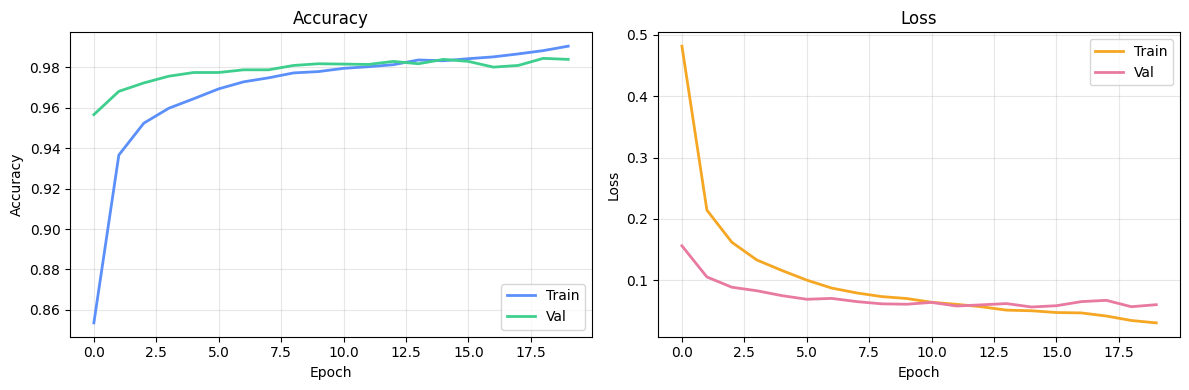

In [ ]:
# ■■ Step 7: Evaluate on test set ■■■■■■■■■■■■■■■■■■■■■■■■■■■■
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy: {test_acc*100:.2f}%') # expect 97-98%
print(f'Test Loss: {test_loss:.4f}')

# ■■ Step 8: Plot training curves ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
ax1.plot(history.history['accuracy'], label='Train', color='#5B8FF9', lw=2)
ax1.plot(history.history['val_accuracy'], label='Val', color='#3ECF8E', lw=2)
ax1.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

# Loss
ax2.plot(history.history['loss'], label='Train', color='#F5A623', lw=2)
ax2.plot(history.history['val_loss'], label='Val', color='#E879A0', lw=2)
ax2.set(title='Loss', xlabel='Epoch', ylabel='Loss')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()
# Reading curves:
# GOOD: both curves decline and stay close together
# OVERFIT: train keeps dropping, val starts rising
# UNDERFIT: both stay high — model too simple or not trained enough

Lab — MNIST Classifier: Target 97%+

Build, train, and evaluate a neural network on the full MNIST dataset. Visualise predictions, inspect the
confusion matrix, examine misclassified digits, and experiment with different architectures to understand how
design choices affect accuracy.

Complete Lab Code

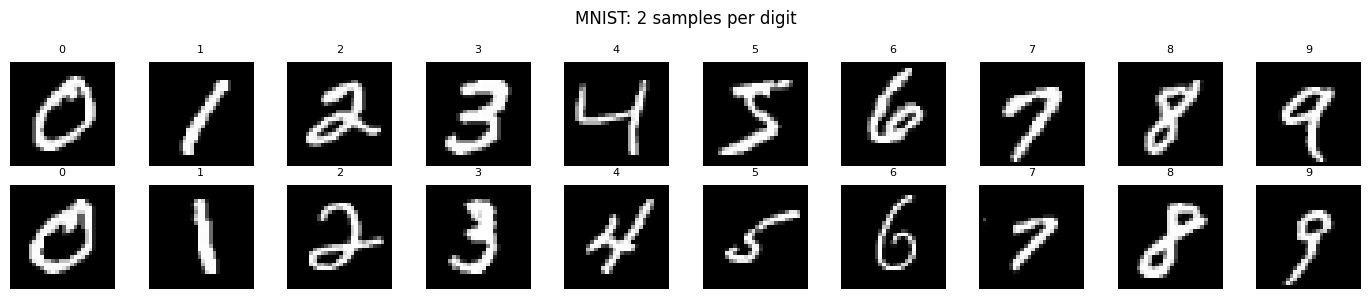

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report
# ■■ Load and preprocess MNIST ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test = X_test.reshape(-1, 784).astype('float32') / 255.0
# ■■ Visualise a sample of training digits ■■■■■■■■■■■■■■■■■■■■■
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for d in range(10):
  for r, offset in enumerate([0, 1]):
    idx = np.where(y_train == d)[0][offset]
    axes[r, d].imshow(X_train[idx].reshape(28,28), cmap='gray')
    axes[r, d].set_title(str(d), fontsize=8); axes[r, d].axis('off')
plt.suptitle('MNIST: 2 samples per digit'); plt.tight_layout(); plt.show()
# ■■ Build model as a reusable function ■■■■■■■■■■■■■■■■■■■■■■■
def make_model(h1=256, h2=128, drop=0.3):
  m = keras.Sequential([
  keras.Input(shape=(784,)),
  layers.Dense(h1, activation='relu'),
  layers.Dropout(drop),
  layers.Dense(h2, activation='relu'),
                       layers.Dropout(drop),
  layers.Dense(10, activation='softmax'),
  ])
  m.compile(optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy'])
  return m
model = make_model()
model.summary()

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.8734 - loss: 0.4148 - val_accuracy: 0.9640 - val_loss: 0.1285
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9473 - loss: 0.1773 - val_accuracy: 0.9708 - val_loss: 0.0937
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9611 - loss: 0.1325 - val_accuracy: 0.9738 - val_loss: 0.0888
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9674 - loss: 0.1065 - val_accuracy: 0.9798 - val_loss: 0.0715
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9718 - loss: 0.0919 - val_accuracy: 0.9813 - val_loss: 0.0653
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9760 - loss: 0.0788 - val_accuracy: 0.9797 - val_loss: 0.0698
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9787 - loss: 0.0692 - val_accuracy: 0.9805 - val_loss: 0.0649
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9801 - loss: 0.0619 - val_acc

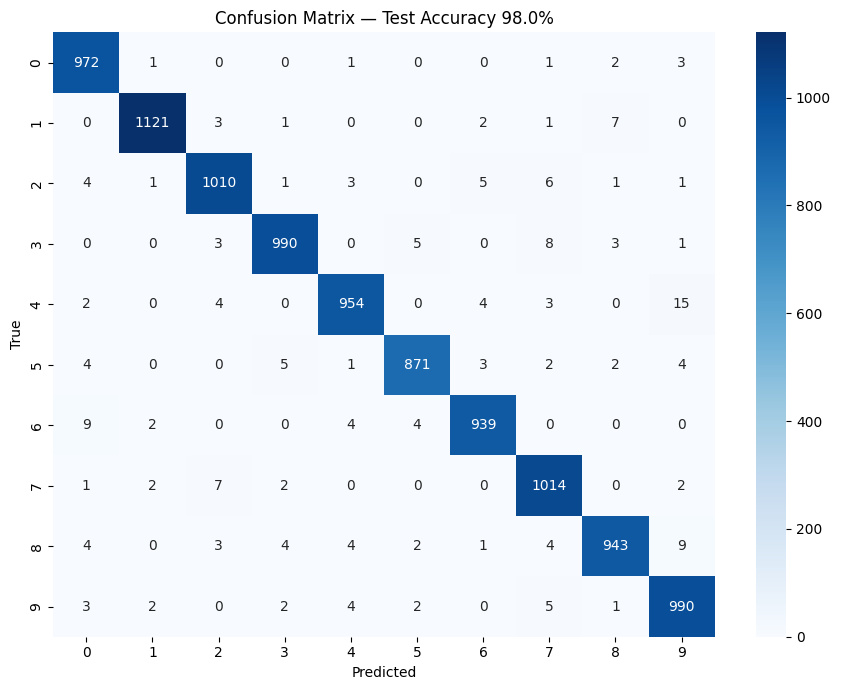

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.99      0.98      0.98      1010
           4       0.98      0.97      0.98       982
           5       0.99      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.97      0.99      0.98      1028
           8       0.98      0.97      0.98       974
           9       0.97      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

Misclassified: 196 out of 10000


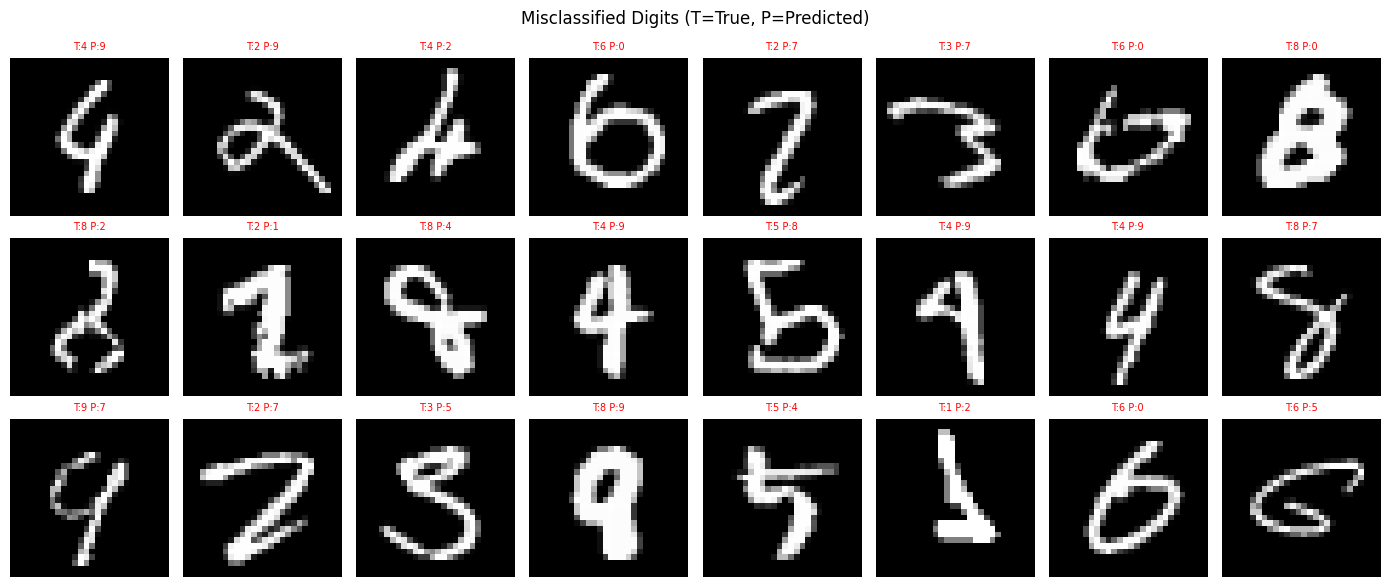

In [ ]:
# ■■ Train ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
history = model.fit(
X_train, y_train, epochs=30, batch_size=128,
validation_split=0.1,
callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
verbose=1)
# ■■ Evaluate ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy: {acc*100:.2f}%')
# ■■ Confusion matrix ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=range(10), yticklabels=range(10))
plt.title(f'Confusion Matrix — Test Accuracy {acc*100:.1f}%')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()
# Diagonal = correctly classified. Off-diagonal = confused pairs.
# Common confusions: 4 vs 9, 3 vs 8, 5 vs 6
print(classification_report(y_test, y_pred))
# ■■ Show misclassified images ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
wrong = np.where(y_pred != y_test)[0]
print(f'Misclassified: {len(wrong)} out of {len(y_test)}')
fig, axes = plt.subplots(3, 8, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
  if i < len(wrong):
    idx = wrong[i]
    ax.imshow(X_test[idx].reshape(28,28), cmap='gray')
    ax.set_title(f'T:{y_test[idx]} P:{y_pred[idx]}',
    color='red', fontsize=7)
  ax.axis('off')
plt.suptitle('Misclassified Digits (T=True, P=Predicted)')
plt.tight_layout(); plt.show()
# ■■ Architecture comparison ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
configs = [
(64, 32, 0.0, 'Small / no dropout'),
(128, 64, 0.2, 'Medium / light dropout'),
(256, 128, 0.3, 'Large / moderate dropout'),
]
for h1, h2, dr, label in configs:
  m = make_model(h1, h2, dr)
  m.fit(X_train, y_train, epochs=15, batch_size=128,
    validation_split=0.1, verbose=0,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)])
_, a = m.evaluate(X_test, y_test, verbose=0)
print(f'{label:35s} Accuracy: {a*100:.2f}%')

Bonus: Visualise What Neurons Learn

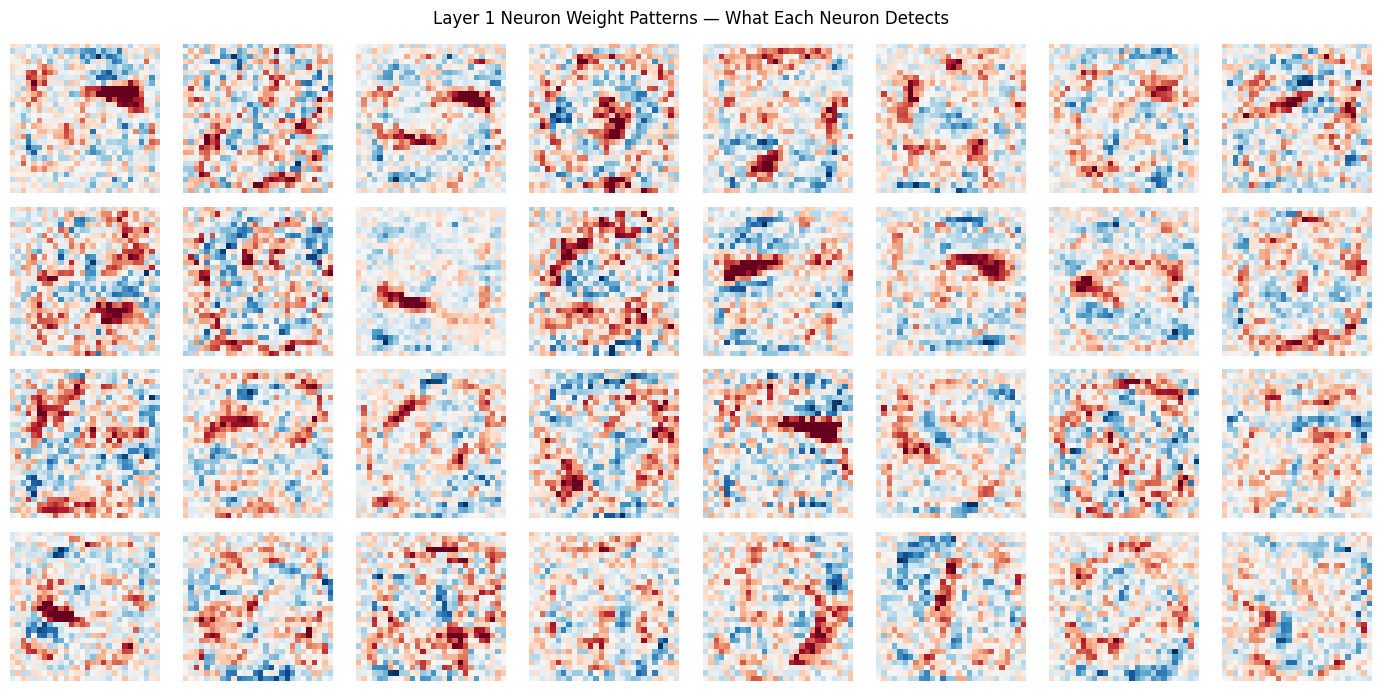

In [ ]:
# ■■ Each Layer 1 neuron has 784 weights (one per pixel) ■■■■■■■■
# Reshape to 28x28 to see which pixel patterns each neuron responds to
weights = model.layers[0].get_weights()[0] # shape: (784, 256)
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
  w = weights[:, i].reshape(28, 28)
  ax.imshow(w, cmap='RdBu', vmin=-w.max(), vmax=w.max())
  ax.axis('off')
plt.suptitle('Layer 1 Neuron Weight Patterns — What Each Neuron Detects')
plt.tight_layout(); plt.show()
# Blue = neuron activated strongly by bright pixel here
# Red = neuron suppressed by bright pixel here

Theory Deep Dive

The Vanishing Gradient Problem


During backpropagation, gradients flow backward through every layer using the chain rule. Each layer multiplies the
gradient by a number. With sigmoid activations, that number is always between 0 and 0.25 (because the sigmoid
derivative never exceeds 0.25).


With 10 layers: 0.25^10 = 0.00000095 — essentially zero. Weights in early layers receive a gradient so small they
barely update. The network's front end stops learning entirely. This was the main barrier to training deep networks
before 2010

Solutions to Vanishing Gradient

ReLU Activation: Gradient of ReLU is 1 for positive inputs. No shrinking. This single change enabled deep
networks to be trained reliably.


Batch Normalisation: Normalises layer inputs during training so gradients stay in a healthy range throughout
the network depth.


Residual Connections (ResNet): Skip connections allow gradients to flow directly backward bypassing layers,
preventing the gradient from being multiplied to zero.

The Universal Approximation Theorem

A neural network with one hidden layer and enough neurons can approximate any continuous function to any
desired accuracy. This is the mathematical guarantee that neural networks are not limited — they can in principle
learn any mapping from inputs to outputs.

In practice: one wide layer requires exponentially many neurons for complex functions. Deep networks (many
layers, moderate width) achieve the same using hierarchical composition — each layer builds on the previous,
reusing simpler patterns to represent complex ones. This is why depth matters more than width.

Parameter Count — Understanding model.summary()

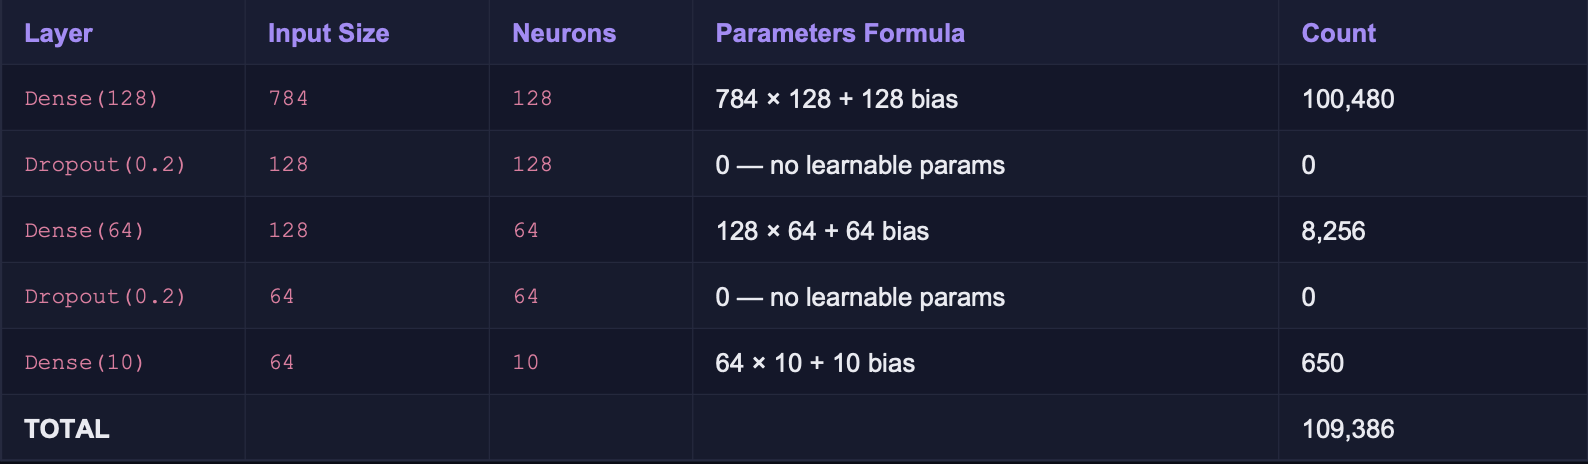

Regularisation Techniques

| Technique               | How It Works                                                                                      | Keras Code                                |
| ----------------------- | ------------------------------------------------------------------------------------------------- | ----------------------------------------- |
| **Dropout**             | Randomly sets a fraction of neurons to zero during each training step, reducing overfitting.      | `Dropout(0.2)`                            |
| **L2 / Weight Decay**   | Adds a penalty for large weights to the loss function, encouraging simpler models.                | `Dense(64, kernel_regularizer='l2')`      |
| **Early Stopping**      | Stops training when validation loss stops improving, preventing overfitting.                      | `EarlyStopping(patience=5)`               |
| **Batch Normalization** | Normalizes layer inputs, stabilizes learning, and often speeds up training.                       | `BatchNormalization()`                    |
| **Data Augmentation**   | Artificially expands the dataset using transformations like flips, rotations, zooms, etc.         | `ImageDataGenerator(...)`                 |
| **More Data**           | The most effective regularization technique; provides the model with more examples to learn from. | Collect or generate more training samples |


Hyperparameter Quick Reference

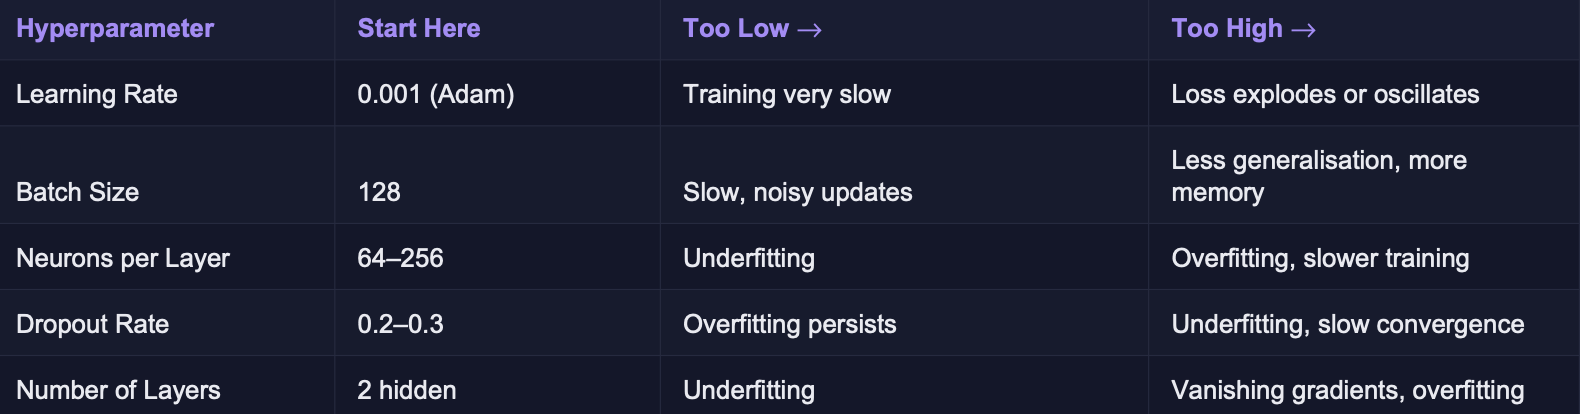

Neural Networks vs Classical ML

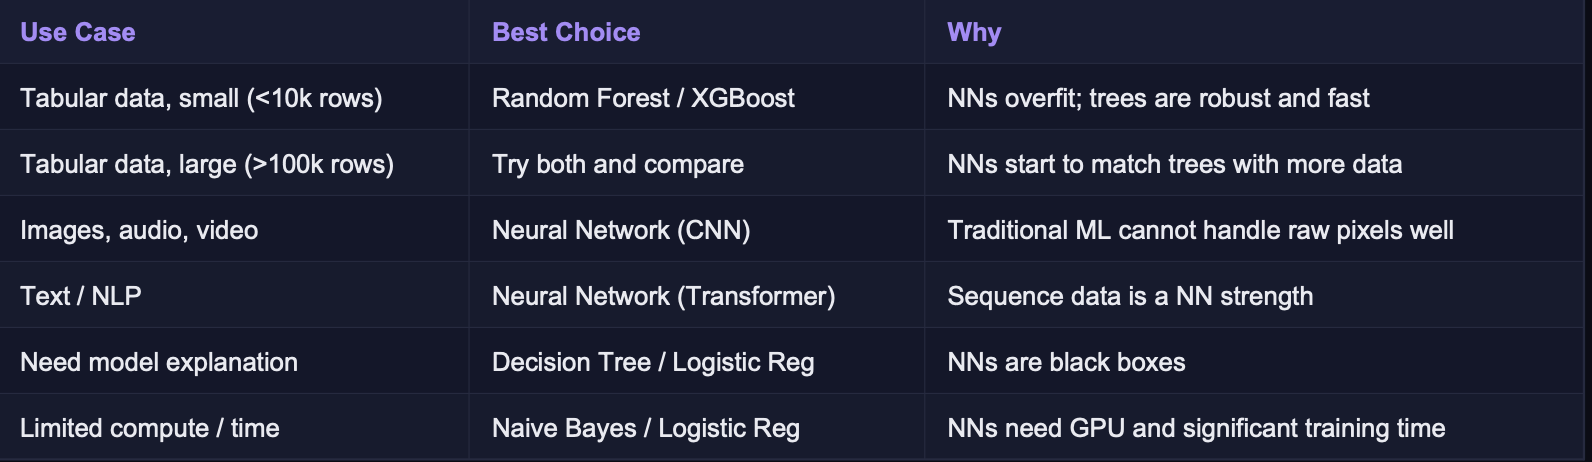